# COMP662 - Synthetic Land-Use Dataset Generation: Runnable Examples

This notebook provides short code examples that match the main practical ideas in the lecture:

- data augmentation vs. synthetic data;
- fidelity checks;
- diversity checks;
- pairwise and nearest-neighbour distances;
- PCA / t-SNE visualisation;
- integer and categorical generation;

The examples use a **small synthetic land-use-style tabular dataset** so that every cell runs quickly.

> **Important:** the purpose is to demonstrate the evaluation workflow clearly, not to build a state-of-the-art generator.


In [1]:
# 1. Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

np.random.seed(42)


## 2. Create a small "real" land-use dataset

We create three land-use classes with correlated continuous features.

The dataset contains:

- `soil_moisture`
- `vegetation_index`
- `temperature`
- `slope`
- `rainfall`
- `tree_count` - integer-valued
- `land_type` - categorical label


In [2]:
# Class-specific means for 5 continuous variables
feature_names = [
    "soil_moisture",
    "vegetation_index",
    "temperature",
    "slope",
    "rainfall"
]

class_names = ["Crop", "Forest", "Urban"]

means = {
    "Crop":   np.array([0.55, 0.65, 18.0,  6.0, 900.0]),
    "Forest": np.array([0.70, 0.82, 15.0, 14.0, 1200.0]),
    "Urban":  np.array([0.30, 0.20, 21.0,  4.0, 700.0])
}

# A shared covariance matrix.
# The off-diagonal values introduce correlations between variables.
cov = np.array([
    [0.010, 0.008, -0.020,  0.010,  1.5],
    [0.008, 0.015, -0.030,  0.015,  2.0],
    [-0.020,-0.030,  3.000, -0.300, -20.0],
    [0.010, 0.015, -0.300,  8.000,  15.0],
    [1.5,    2.0,  -20.0,  15.0, 12000.0]
])

def make_real_data(n_per_class=400):
    rows = []

    for land_type in class_names:
        X = np.random.multivariate_normal(
            mean=means[land_type],
            cov=cov,
            size=n_per_class
        )

        df = pd.DataFrame(X, columns=feature_names)

        # Keep some naturally bounded variables in sensible ranges
        df["soil_moisture"] = df["soil_moisture"].clip(0, 1)
        df["vegetation_index"] = df["vegetation_index"].clip(0, 1)
        df["slope"] = df["slope"].clip(0)

        # Integer-valued feature
        expected_trees = {
            "Crop": 25,
            "Forest": 120,
            "Urban": 5
        }[land_type]

        df["tree_count"] = np.random.poisson(expected_trees, size=n_per_class)
        df["land_type"] = land_type
        rows.append(df)

    return pd.concat(rows, ignore_index=True)

real = make_real_data()
real.head()


,soil_moisture,vegetation_index,temperature,slope,rainfall,tree_count,land_type
0,0.689935,0.815953,16.960567,6.261224,845.585347,24,Crop
1,0.488388,0.625334,16.883891,1.501173,925.652310,23,Crop
2,0.488919,0.380961,17.425431,7.356217,950.762486,25,Crop
3,0.560908,0.512918,17.200424,8.907532,961.590834,16,Crop
4,0.439970,0.442451,18.114788,6.430626,739.445218,30,Crop


In [3]:
print(real.shape)
print()
print(real["land_type"].value_counts())
print()
print(real.describe().round(2))


(1200, 7)

land_type
Crop      400
Forest    400
Urban     400
Name: count, dtype: int64

       soil_moisture  vegetation_index  temperature    slope  rainfall  \
count        1200.00           1200.00      1200.00  1200.00   1200.00   
mean            0.51              0.56        18.04     8.14    932.70   
std             0.19              0.29         3.04     5.16    233.53   
min             0.03              0.00         8.38     0.00    313.41   
25%             0.36              0.28        15.72     4.17    748.29   
50%             0.54              0.64        17.91     7.13    905.72   
75%             0.66              0.78        20.26    12.52   1124.95   
max             1.00              1.00        25.97    22.20   1529.47   

       tree_count  
count     1200.00  
mean        50.06  
std         50.76  
min          0.00  
25%          7.00  
50%         25.00  
75%        112.00  
max        152.00  


## 3. Keep a real test set

A generative model should be fitted using the **training data only**.

The real test set remains untouched and will later be used to evaluate downstream utility.


In [4]:
train_real, test_real = train_test_split(
    real,
    test_size=0.25,
    stratify=real["land_type"],
    random_state=42
)

print("Training samples:", len(train_real))
print("Test samples:", len(test_real))


Training samples: 900
Test samples: 300


## 4. Data augmentation

Data augmentation modifies existing observations.

For tabular continuous data, a simple example is adding small noise.


In [5]:
augmented = train_real.copy()

noise_columns = feature_names

for col in noise_columns:
    std = train_real[col].std()
    augmented[col] = augmented[col] + np.random.normal(
        0,
        0.02 * std,
        size=len(augmented)
    )

# Keep bounded variables valid
augmented["soil_moisture"] = augmented["soil_moisture"].clip(0, 1)
augmented["vegetation_index"] = augmented["vegetation_index"].clip(0, 1)
augmented["slope"] = augmented["slope"].clip(0)

print("Original row:")
display(train_real.iloc[[0]])

print("Augmented version:")
display(augmented.iloc[[0]])


Original row:


,soil_moisture,vegetation_index,temperature,slope,rainfall,tree_count,land_type
358,0.618996,0.765783,17.951034,5.947051,1105.41571,30,Crop


Augmented version:


,soil_moisture,vegetation_index,temperature,slope,rainfall,tree_count,land_type
358,0.610978,0.766463,17.967014,5.945912,1109.069441,30,Crop


## 5. A simple statistical synthetic-data generator

To keep the example straightforward, we fit a separate multivariate Gaussian distribution for each class.

This is **not** intended as a replacement for VAE, GAN, or diffusion models. It simply demonstrates the generation and evaluation workflow.


In [6]:
def fit_class_gaussian_generator(data):
    model = {}

    for cls in class_names:
        subset = data[data["land_type"] == cls]

        model[cls] = {
            "mean": subset[feature_names].mean().values,
            "cov": subset[feature_names].cov().values,
            "tree_lambda": subset["tree_count"].mean()
        }

    return model


def generate_synthetic(model, n_per_class=300):
    rows = []

    for cls in class_names:
        X = np.random.multivariate_normal(
            model[cls]["mean"],
            model[cls]["cov"],
            size=n_per_class
        )

        df = pd.DataFrame(X, columns=feature_names)

        df["soil_moisture"] = df["soil_moisture"].clip(0, 1)
        df["vegetation_index"] = df["vegetation_index"].clip(0, 1)
        df["slope"] = df["slope"].clip(0)

        # Integer-valued feature
        df["tree_count"] = np.random.poisson(
            model[cls]["tree_lambda"],
            size=n_per_class
        )

        df["land_type"] = cls
        rows.append(df)

    return pd.concat(rows, ignore_index=True)


generator = fit_class_gaussian_generator(train_real)
synthetic = generate_synthetic(generator, n_per_class=300)

synthetic.head()


,soil_moisture,vegetation_index,temperature,slope,rainfall,tree_count,land_type
0,0.575544,0.603144,17.392780,6.096220,1147.731933,28,Crop
1,0.742003,0.810886,14.761111,3.563131,995.968558,31,Crop
2,0.474499,0.633036,18.746909,7.923790,812.222679,20,Crop
3,0.555581,0.732422,18.018318,6.170936,801.145515,32,Crop
4,0.473166,0.550025,17.636153,9.693370,778.167328,24,Crop


# Fidelity

The lecture defines fidelity as how closely synthetic data matches the statistical properties of real data.

We start with univariate checks, then move to multivariate checks.


## 6. Univariate fidelity: histogram


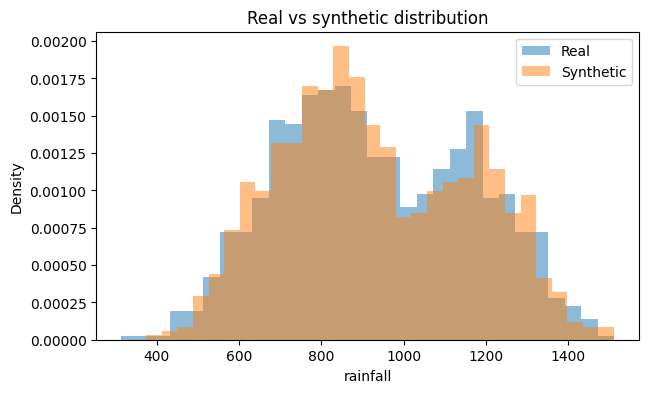

In [7]:
feature = "rainfall"

plt.figure(figsize=(7, 4))
plt.hist(train_real[feature], bins=30, alpha=0.5, density=True, label="Real")
plt.hist(synthetic[feature], bins=30, alpha=0.5, density=True, label="Synthetic")
plt.xlabel(feature)
plt.ylabel("Density")
plt.title("Real vs synthetic distribution")
plt.legend()
plt.show()


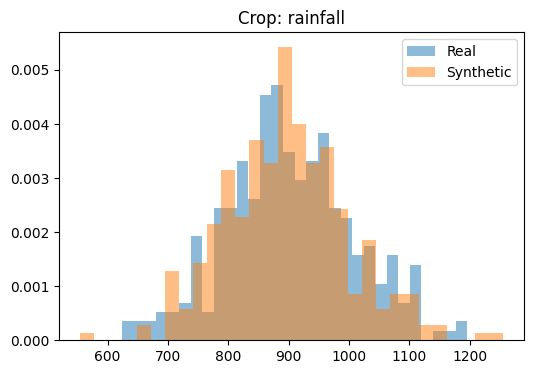

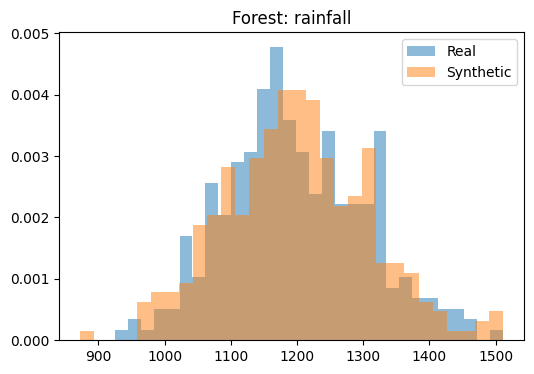

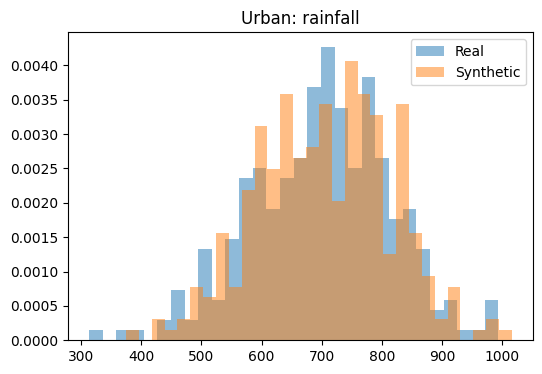

In [9]:
for cls in class_names:
    plt.figure(figsize=(6,4))

    real_subset = train_real[train_real["land_type"] == cls]
    syn_subset = synthetic[synthetic["land_type"] == cls]

    plt.hist(real_subset[feature],
             bins=30,
             density=True,
             alpha=0.5,
             label="Real")

    plt.hist(syn_subset[feature],
             bins=30,
             density=True,
             alpha=0.5,
             label="Synthetic")

    plt.title(f"{cls}: {feature}")
    plt.legend()
    plt.show()

## 7. Univariate fidelity: summary statistics


In [10]:
summary = pd.DataFrame({
    "real_mean": train_real[feature_names].mean(),
    "synthetic_mean": synthetic[feature_names].mean(),
    "real_std": train_real[feature_names].std(),
    "synthetic_std": synthetic[feature_names].std()
})

summary.round(3)


,real_mean,synthetic_mean,real_std,synthetic_std
soil_moisture,0.513,0.509,0.194,0.192
vegetation_index,0.557,0.556,0.287,0.283
temperature,18.080,18.032,3.049,3.038
slope,8.157,8.008,5.206,5.082
rainfall,933.981,933.490,232.421,229.974


## 8. Class proportions

A conditional generator may also need to preserve, or deliberately control, class proportions.


In [11]:
class_compare = pd.DataFrame({
    "Real": train_real["land_type"].value_counts(normalize=True),
    "Synthetic": synthetic["land_type"].value_counts(normalize=True)
})

class_compare


,Real,Synthetic
land_type,,
Crop,0.333333,0.333333
Forest,0.333333,0.333333
Urban,0.333333,0.333333


## 9. Multivariate fidelity: correlation matrices

Matching individual features is not enough. We also want to preserve relationships between features.


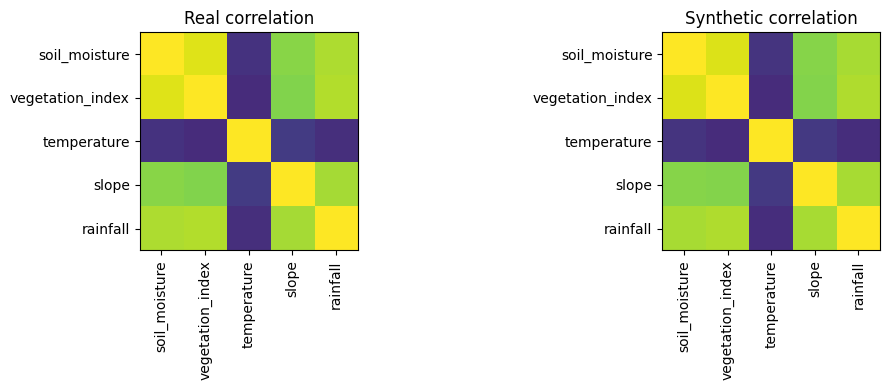

Frobenius norm of correlation difference: 0.0394


In [12]:
real_corr = train_real[feature_names].corr()
syn_corr = synthetic[feature_names].corr()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im1 = axes[0].imshow(real_corr, vmin=-1, vmax=1)
axes[0].set_title("Real correlation")
axes[0].set_xticks(range(len(feature_names)), feature_names, rotation=90)
axes[0].set_yticks(range(len(feature_names)), feature_names)

im2 = axes[1].imshow(syn_corr, vmin=-1, vmax=1)
axes[1].set_title("Synthetic correlation")
axes[1].set_xticks(range(len(feature_names)), feature_names, rotation=90)
axes[1].set_yticks(range(len(feature_names)), feature_names)

plt.tight_layout()
plt.show()

correlation_difference = np.linalg.norm(
    real_corr.values - syn_corr.values,
    ord="fro"
)

print("Frobenius norm of correlation difference:",
      round(correlation_difference, 4))


## 10. Multivariate fidelity: covariance matrices

Covariance preserves the original feature scales.

Because different variables have very different units, covariance values can also differ greatly in magnitude.


In [13]:
real_cov = train_real[feature_names].cov()
syn_cov = synthetic[feature_names].cov()

covariance_difference = np.linalg.norm(
    real_cov.values - syn_cov.values,
    ord="fro"
)

print("Real covariance matrix:")
display(real_cov.round(2))

print("Synthetic covariance matrix:")
display(syn_cov.round(2))

print("Frobenius norm of covariance difference:",
      round(covariance_difference, 2))


Real covariance matrix:


,soil_moisture,vegetation_index,temperature,slope,rainfall
soil_moisture,0.04,0.05,-0.42,0.65,33.97
vegetation_index,0.05,0.08,-0.66,0.92,51.14
temperature,-0.42,-0.66,9.30,-10.39,-516.06
slope,0.65,0.92,-10.39,27.10,882.93
rainfall,33.97,51.14,-516.06,882.93,54019.31


Synthetic covariance matrix:


,soil_moisture,vegetation_index,temperature,slope,rainfall
soil_moisture,0.04,0.05,-0.41,0.62,32.74
vegetation_index,0.05,0.08,-0.64,0.91,49.67
temperature,-0.41,-0.64,9.23,-10.27,-514.39
slope,0.62,0.91,-10.27,25.83,860.59
rainfall,32.74,49.67,-514.39,860.59,52888.09


Frobenius norm of covariance difference: 1131.67


## 11. PCA projection

Fit PCA on the **real training data**, then project both datasets into the same PCA coordinate system.


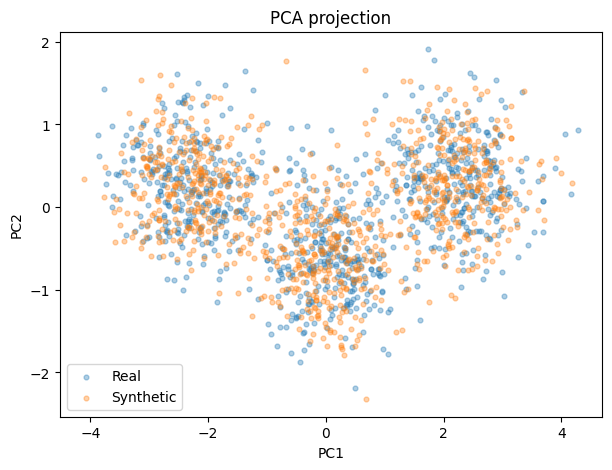

Explained variance ratio: [0.781 0.093]


In [14]:
# Standardise first because the features have different units
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(train_real[feature_names])
X_syn_scaled = scaler.transform(synthetic[feature_names])

pca = PCA(n_components=2)
real_pca = pca.fit_transform(X_real_scaled)
syn_pca = pca.transform(X_syn_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(real_pca[:, 0], real_pca[:, 1],
            s=12, alpha=0.35, label="Real")
plt.scatter(syn_pca[:, 0], syn_pca[:, 1],
            s=12, alpha=0.35, label="Synthetic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection")
plt.legend()
plt.show()

print("Explained variance ratio:",
      np.round(pca.explained_variance_ratio_, 3))


## 12. t-SNE visualisation

t-SNE focuses strongly on **local neighbourhood structure**.

For a fair visual comparison, run t-SNE on a combined sample of real and synthetic observations.


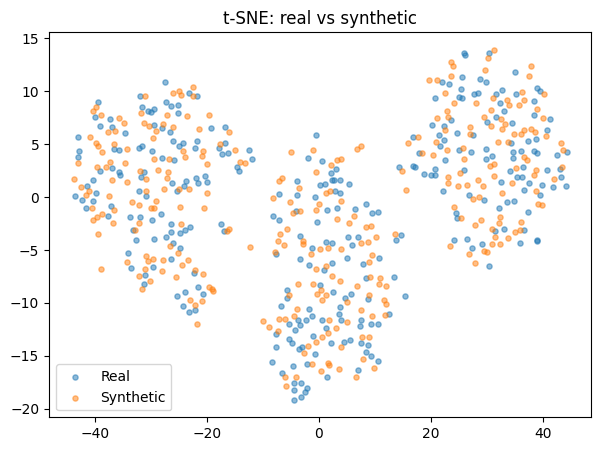

In [15]:
# Use a moderate sample so that the demonstration runs quickly
n_show = 300

real_sample = train_real[feature_names].sample(
    n=n_show, random_state=1
)
syn_sample = synthetic[feature_names].sample(
    n=n_show, random_state=1
)

combined = pd.concat([real_sample, syn_sample], ignore_index=True)

combined_scaled = StandardScaler().fit_transform(combined)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

embedding = tsne.fit_transform(combined_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(
    embedding[:n_show, 0],
    embedding[:n_show, 1],
    s=14,
    alpha=0.5,
    label="Real"
)
plt.scatter(
    embedding[n_show:, 0],
    embedding[n_show:, 1],
    s=14,
    alpha=0.5,
    label="Synthetic"
)
plt.title("t-SNE: real vs synthetic")
plt.legend()
plt.show()


## 13. Optional: UMAP

UMAP is not part of scikit-learn. This cell runs only if `umap-learn` is installed.

Install separately with:

```bash
pip install umap-learn
```


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


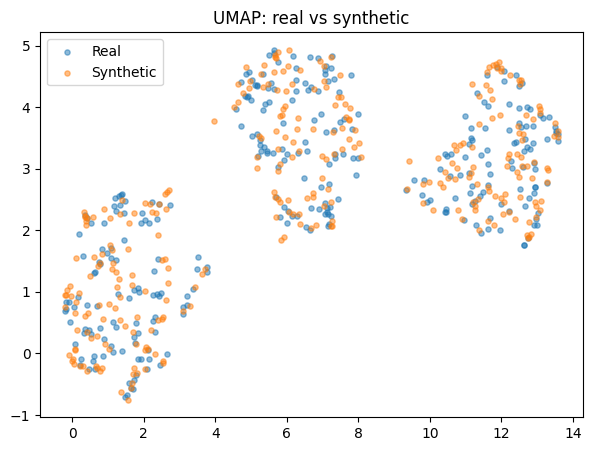

In [16]:
try:
    import umap

    reducer = umap.UMAP(
        n_components=2,
        random_state=42
    )

    embedding_umap = reducer.fit_transform(combined_scaled)

    plt.figure(figsize=(7, 5))
    plt.scatter(
        embedding_umap[:n_show, 0],
        embedding_umap[:n_show, 1],
        s=14,
        alpha=0.5,
        label="Real"
    )
    plt.scatter(
        embedding_umap[n_show:, 0],
        embedding_umap[n_show:, 1],
        s=14,
        alpha=0.5,
        label="Synthetic"
    )
    plt.title("UMAP: real vs synthetic")
    plt.legend()
    plt.show()

except ImportError:
    print("UMAP is not installed. Skipping this optional example.")


# Diversity

Diversity asks whether generated samples cover enough different cases.

We will compare:

1. pairwise-distance distributions - global spread;
2. nearest-neighbour distances - local density;
3. feature-range coverage.


## 14. Pairwise-distance distribution

Distances should be calculated after scaling the features; otherwise a large-unit feature such as rainfall can dominate the result.

To keep the demonstration efficient, we calculate pairwise distances on a random subsample.


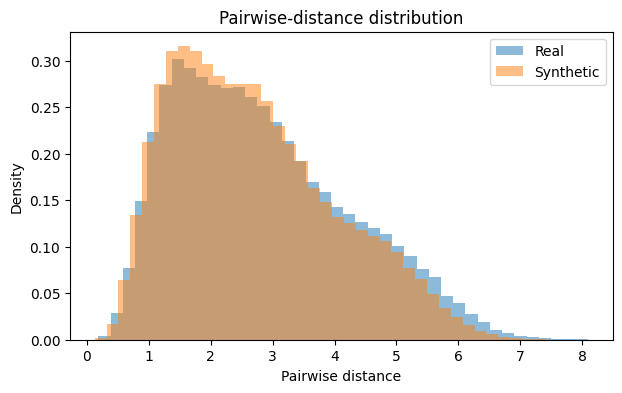

Mean real pairwise distance: 2.841
Mean synthetic pairwise distance: 2.703


In [17]:
n_distance = 400

real_sub = train_real[feature_names].sample(
    n=n_distance, random_state=10
)
syn_sub = synthetic[feature_names].sample(
    n=n_distance, random_state=10
)

distance_scaler = StandardScaler()
real_sub_scaled = distance_scaler.fit_transform(real_sub)
syn_sub_scaled = distance_scaler.transform(syn_sub)

# Full distance matrices for the small subsamples
D_real = pairwise_distances(real_sub_scaled)
D_syn = pairwise_distances(syn_sub_scaled)

# Keep upper triangle only: each pair appears once
upper = np.triu_indices(n_distance, k=1)

real_pairwise = D_real[upper]
syn_pairwise = D_syn[upper]

plt.figure(figsize=(7, 4))
plt.hist(real_pairwise, bins=40, alpha=0.5, density=True, label="Real")
plt.hist(syn_pairwise, bins=40, alpha=0.5, density=True, label="Synthetic")
plt.xlabel("Pairwise distance")
plt.ylabel("Density")
plt.title("Pairwise-distance distribution")
plt.legend()
plt.show()

print("Mean real pairwise distance:", round(real_pairwise.mean(), 3))
print("Mean synthetic pairwise distance:", round(syn_pairwise.mean(), 3))


## 15. Nearest-neighbour distance

For each sample, find the closest **other sample in the same dataset**.

This gives a simple measure of local density.


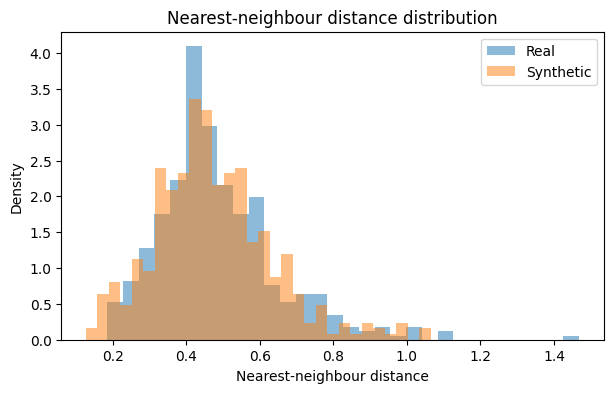

Mean real NN distance: 0.486
Mean synthetic NN distance: 0.475


In [18]:
def nearest_neighbour_distances(X):
    # n_neighbors=2 because each point's first neighbour is itself
    nn = NearestNeighbors(n_neighbors=2)
    nn.fit(X)

    distances, indices = nn.kneighbors(X)

    # Column 0 is distance to itself = 0
    # Column 1 is distance to the nearest other sample
    return distances[:, 1]


real_nn = nearest_neighbour_distances(real_sub_scaled)
syn_nn = nearest_neighbour_distances(syn_sub_scaled)

plt.figure(figsize=(7, 4))
plt.hist(real_nn, bins=30, alpha=0.5, density=True, label="Real")
plt.hist(syn_nn, bins=30, alpha=0.5, density=True, label="Synthetic")
plt.xlabel("Nearest-neighbour distance")
plt.ylabel("Density")
plt.title("Nearest-neighbour distance distribution")
plt.legend()
plt.show()

print("Mean real NN distance:", round(real_nn.mean(), 3))
print("Mean synthetic NN distance:", round(syn_nn.mean(), 3))


### Interpretation

- **Much smaller synthetic NN distances:** generated samples may be too concentrated.
- **Similar distributions:** local density is similar.
- **Much larger synthetic NN distances:** generated samples may be too sparse or overly dispersed.

Do not try to simply maximise the distance. The metric should be interpreted together with fidelity and coverage.


## 16. Feature-range coverage

A very simple diversity check is whether the synthetic dataset covers the range of each real feature.


In [19]:
coverage_rows = []

for col in feature_names:
    real_min = train_real[col].min()
    real_max = train_real[col].max()
    syn_min = synthetic[col].min()
    syn_max = synthetic[col].max()

    real_range = real_max - real_min

    overlap = max(
        0,
        min(real_max, syn_max) - max(real_min, syn_min)
    )

    coverage = overlap / real_range if real_range > 0 else np.nan

    coverage_rows.append({
        "feature": col,
        "real_min": real_min,
        "real_max": real_max,
        "synthetic_min": syn_min,
        "synthetic_max": syn_max,
        "range_coverage": coverage
    })

pd.DataFrame(coverage_rows).round(3)


,feature,real_min,real_max,synthetic_min,synthetic_max,range_coverage
0,soil_moisture,0.032,1.000,0.000,0.975,0.975
1,vegetation_index,0.000,1.000,0.000,1.000,1.000
2,temperature,8.379,25.969,10.407,27.745,0.885
3,slope,0.000,22.155,0.000,20.406,0.921
4,rainfall,313.405,1511.000,374.763,1511.281,0.949


# Generating Discrete Data

The lecture distinguishes:

- integer-valued features;
- categorical features.


## 17. Integer-valued feature: round and clip

A model may output a continuous value even when the desired feature is integer-valued.


In [22]:
continuous_output = np.array([12.2, 17.8, -1.4, 105.6, 43.1])

integer_output = np.rint(continuous_output)
integer_output = np.clip(integer_output, 0, 100).astype(int)

print("Continuous model output:", continuous_output)
print("After round + clip:     ", integer_output)


Continuous model output: [ 12.2  17.8  -1.4 105.6  43.1]
After round + clip:      [ 12  18   0 100  43]


## 18. Categorical feature: sample from category probabilities


In [23]:
categories = np.array(["Crop", "Forest", "Urban"])
probabilities = np.array([0.20, 0.55, 0.25])

samples = np.random.choice(
    categories,
    size=10,
    p=probabilities
)

print(samples)


['Crop' 'Forest' 'Urban' 'Forest' 'Crop' 'Urban' 'Forest' 'Crop' 'Crop'
 'Forest']


## 19. Gumbel-Softmax

Gumbel-Softmax provides a differentiable approximation to sampling a discrete category during neural-network training.

This is a minimal PyTorch demonstration.


In [24]:
try:
    import torch
    import torch.nn.functional as F

    # Unnormalised category scores
    logits = torch.tensor([[2.0, 1.0, 0.2]])

    soft_sample = F.gumbel_softmax(
        logits,
        tau=1.0,
        hard=False
    )

    hard_sample = F.gumbel_softmax(
        logits,
        tau=1.0,
        hard=True
    )

    print("Soft Gumbel-Softmax sample:")
    print(soft_sample)

    print("\nHard one-hot sample:")
    print(hard_sample)

except ImportError:
    print("PyTorch is not installed. Skipping this optional example.")


Soft Gumbel-Softmax sample:
tensor([[0.7916, 0.1485, 0.0599]])

Hard one-hot sample:
tensor([[1., 0., 0.]])


# Final Takeaways

A practical synthetic-data evaluation should combine several complementary checks:

### Fidelity
- feature distributions;
- summary statistics;
- correlation / covariance;
- PCA / t-SNE / UMAP.

### Diversity
- pairwise-distance distribution;
- nearest-neighbour distance;
- feature-range / class coverage.
- PCA / t-SNE / UMAP.

### Utility
- evaluate downstream performance on an untouched **real** test set.

### Privacy
- check whether generated samples are suspiciously close to training observations.

**No single metric is enough.**
